In [1]:
import os
import soundfile as sf           
import numpy as np               
import matplotlib.pyplot as plt  
from scipy.signal import welch   
from scipy.io import wavfile
import scipy.signal as sps
import librosa
import torch
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
import math

from sampling import module_functions
from convolving import module_functions_conv
from IPython.display import Audio
from IPython import display

import torch.nn as nn
import torchvision
from PIL import Image
import torchvision.transforms as transforms
import torch.nn.functional as Fu
import sounddevice as sd

# Desarrollo de la experiencia práctica de convolución con datos de audio

## Objetivos del experimento

> Uno de los objetivos de este simple experimento es trabajar con datos de audio y comprender la operación llamada convolución.

> Otro de los objetivos es observar auditivamente el efecto que tiene la convolución sobre una señal limpia (sin distorsión) cuando ésta se convoluciona con las respuestas al impulso de dos salas diferentes acústicamente: anecoica y reverberante. 

## Descripción del experimento

> La convolución entre dos señales de audio, genera un tercer audio. 

> Este tercer audio nos permite extraer características de un canal de transmisión acústico.

> Para manipular los datos se usa la librería <span style="color:red">**TorchAudio**</span> [https://arxiv.org/abs/2110.15018]. 

> Nuestro objetivo al seleccionar Torchaudio es aplicar <span style="color:red">**PyTorch**</span> durante la manipulación de nuestros datos capturados [https://pytorch.org/audio/stable/index.html].

> Se usan aquí dos señales de audio grabadas con un teléfono celular.

> Las señales capturadas representan el sonido que se genera por un impulso que se emite y que se propaga a través de un espacio acústico.

> Se realiza la misma prueba impulsiva pero en dos salas distintas acústicamente.

> La primera sala corresponde a <span style="color:red">**sala anecoica**</span>. Para más información el siguiente link puede ser de interés [https://www.southampton.ac.uk/engineering/outreach/activities/acoustic_test.page]

> La segunda sala es una <span style="color:red">**sala reverberante**</span>. Más información, ver enlace:  [https://isvr.co.uk/archive/reverberation-chambers/]

### Señal de prueba (limpia)

> Se usa una tercera señal de audio llamada <span style="color:red">**señal de prueba**</span>. Esta última señal, está limpia, no tiene ninguna distorsión y se emplea para realizar la operación de convolución.

> Usando por separado, el audio de la sala anecoica y el audio de la sala reverberante, se convolucionan con la señal de prueba.

### Discriminación auditiva entre datos de audio convolucionados

> Se escuchan posteriormente los resultados de la convolución.

> Al escuchar la señal de prueba que se convoluciona con la señal impulsiva capturada en la sala anecoica, ésta resulta ser bastante similar a la señal de prueba original. 

> La razón se debe a que el impulso generado en la sala anecoica se propaga en teoría en un campo acústico sin reflexiones del sonido. Esta respuesta de la sala anecoica al impulso, al convolucionarse con la señal de prueba, no la distorsiona y, por lo tanto, se percibe auditivamente como muy similar a la señal limpia.

> Mientras que al escuchar la señal de prueba, convolucionada con la señal de audio capturada en la sala reverberante, se perciben las diferencias auditivamente. 

> Esto se debe a que el impulso que se genera en una sala reverberante se propaga por la sala que se  caracteriza por ser un campo acústico altamente difuso, con múltiples reflexiones. Cuando se convoluciona la respuesta al impulso de la sala reverberante, con la señal de prueba, la convolución le confiere a la señal de prueba las características altamente reverberantes, afectándola de manera fuerte a la señal de prueba. Las diferencias entre la señal de prueba original y la señal convolucionada, de manera auditiva se perciben claramente.   

## Manipulación de datos de audio

> La frecuencia de muestreo de los audios que se grabaron usando los teléfonos celulares era originalmente 38000 muestras por segundo.

> Los audio grabados estaban en formato estéreo.

> Se bajó a 16000 muestras por segundo la frecuencia de muestreo.

> Solamente se usó un solo canl (mono).

> La explicación para estas dos manipulaciones es no colapsar el computador cuando se realice la convolución en sus computadoes personales. 

## Rutas de acceso

In [2]:
_SAMPLE_DIR_AUD  = "audio_data"

audio_path = os.path.join(_SAMPLE_DIR_AUD, "anechoic16.wav")
os.makedirs(_SAMPLE_DIR_AUD, exist_ok=True)

audio_path_rev = os.path.join(_SAMPLE_DIR_AUD, "rev16.wav")
os.makedirs(_SAMPLE_DIR_AUD, exist_ok=True)

## Cargar los datos de audios

> Para obtener los datos de audio se usa <span style="color:red">**torchaudio.load()**</span>.

## Sala anecoica: Datos del audio y frecuencia de muestreo

In [3]:
audio_anechoic, sampling_frequency = torchaudio.load(audio_path)

> Lo que retornó es una tupla.

> Tenemos dos fuentes de información importantes. La primera es información de las amplitudes de todas las muestras discretas de señal. Esto representa la forma de onda temporal (waveform). Es un objeto <span style="color:red">**Tensor**</span>. La segunda es información de la frecuencia de muestreo (int) del audio digital.

> En PyTorch, un tensor se refiere a un arreglo multidimensional. Este contiene elementos de un mismo tiponde datos. 

> Por defecto, el objeto tensor es dtype=torch.float32 y los valores de las amplitudes de las muestras de audio están variando entre [-1.0, 1.0].

## Metadata del audio anecoico

> Se puede obtener información adicional de la señal que fue grabada.

In [4]:
metadata_anechoic = torchaudio.info(audio_path)
print(metadata_anechoic)

AudioMetaData(sample_rate=16000, num_frames=4739, num_channels=1, bits_per_sample=16, encoding=PCM_S)


In [5]:
print(metadata_anechoic.sample_rate)

16000


## Módulo display de IPython

> La clase IPython.display.Audio() crea un objeto de audio. 

> Cuando se retorna este objeto y pasa por la función display function, resulta en un control del audio que se mostrará en el cuadernillo.

In [6]:
Audio(audio_anechoic.numpy()[0], rate = sampling_frequency)

## Sala reverberante: Datos del audio y frecuencia de muestreo

In [7]:
audio_reverberant, sampling_frequency = torchaudio.load(audio_path_rev)

## Metadata del audio reverberante

In [8]:
metadata_reverberant = torchaudio.info(audio_path_rev)
print(metadata_reverberant)

AudioMetaData(sample_rate=16000, num_frames=38920, num_channels=1, bits_per_sample=16, encoding=PCM_S)


In [9]:
print(metadata_reverberant.sample_rate)

16000


## Módulo display de IPython

In [10]:
Audio(audio_reverberant.numpy()[0], rate=sampling_frequency)

## Estadisticas globales de audio anecoico

> En TorchAudio, la función <span style="color:red">**print_stats()**</span> permite obtener una información global de los datos.

In [11]:
module_functions_conv.print_stats(audio_anechoic, sample_rate=sampling_frequency)

Sample Rate: 16000
Shape: (1, 4739)
Dtype: torch.float32
 - Max:      0.990
 - Min:     -0.708
 - Mean:     0.002
 - Std Dev:  0.043

tensor([[-0.0003, -0.0002, -0.0005,  ...,  0.0018,  0.0016,  0.0017]])



## Estadisticas globales de audio reverberante

In [12]:
module_functions_conv.print_stats(audio_reverberant, sample_rate=sampling_frequency)

Sample Rate: 16000
Shape: (1, 38920)
Dtype: torch.float32
 - Max:      0.605
 - Min:     -0.717
 - Mean:    -0.000
 - Std Dev:  0.090

tensor([[-0.0012,  0.0008,  0.0030,  ..., -0.0049, -0.0201, -0.0182]])



## Visualización Amplitud versus Tiempo de las respuestas de cada sala a un impulso

> En TorchAudio, la función <span style="color:red">**plot_waveform**</span> permite visualizar la información global de los datos de amplitudes de las muestras discretas, en función de la variable independiente tiempo.

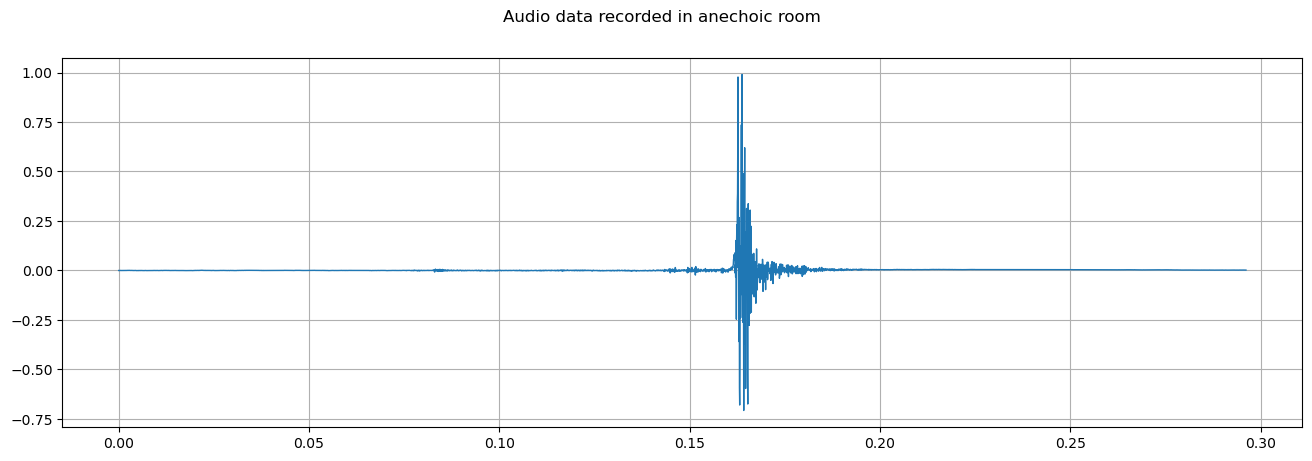

In [13]:
module_functions_conv.plot_waveform(audio_anechoic, sampling_frequency, title = "Audio data recorded in anechoic room")

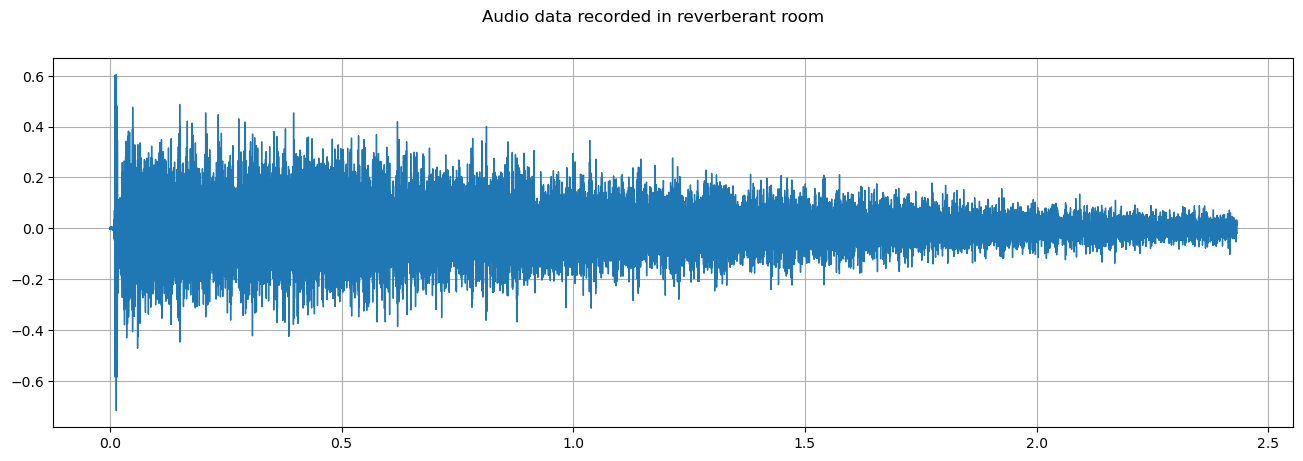

In [14]:
module_functions_conv.plot_waveform(audio_reverberant, sampling_frequency, title = "Audio data recorded in reverberant room")

## Explorar la forma de los tensores

> En PyTorch, la forma de un tensor se entiende como el número de elementos a lo largo de cada dimensión del tensor. 

> Para explorar la forma del tensor en PyTorch, se use el método <span style="color:red">**size()**</span>.

In [15]:
print(audio_anechoic.size())

torch.Size([1, 4739])


In [16]:
print(audio_anechoic.size()[0])

1


In [17]:
print(audio_anechoic.size()[1])

4739


In [18]:
print(audio_reverberant.size())

torch.Size([1, 38920])


In [19]:
print(audio_reverberant.size()[1])

38920


## Explorar audio de prueba

In [20]:
audio_path_happybirthday = os.path.join(_SAMPLE_DIR_AUD, "mercury_.wav")
os.makedirs(_SAMPLE_DIR_AUD, exist_ok=True)

In [21]:
audio_happybirthday, sampling_frequency = torchaudio.load(audio_path_happybirthday)

In [22]:
metadata_happybirthday = torchaudio.info(audio_path_happybirthday)
print(metadata_happybirthday)

AudioMetaData(sample_rate=16000, num_frames=46626, num_channels=1, bits_per_sample=16, encoding=PCM_S)


In [23]:
Audio(audio_happybirthday.numpy()[0], rate = sampling_frequency)

## Padding entre audio de prueba y audio anecoico

> La función <span style="color:red">**pad**</span> de PyTorch, está disponible en la librería Torch.

> El <span style="color:red">**padding**</span> se usa para lograr que se ajusten los tamaños de los tensores.

In [24]:
audio_anech = torch.nn.functional.pad(audio_happybirthday, (audio_anechoic.size()[1]-1, 0))

## Aplicación de convolución 1D entre audio de prueba y audio anecoico  

In [25]:
audio_conv_anechoic = torch.nn.functional.conv1d(audio_anech[None, ...], audio_anechoic[None, ...])[0]

In [26]:
Audio(audio_conv_anechoic.numpy()[0], rate=sampling_frequency)

## Padding entre audio de prueba y audio reverberante

In [37]:
audio_rev = torch.nn.functional.pad(audio_happybirthday, (audio_reverberant.size()[1]-1, 0))

## Aplicación de convolución 1D entre audio de prueba y audio reverberante

In [38]:
audio_conv_rev = torch.nn.functional.conv1d(audio_rev[None, ...], audio_reverberant[None, ...])[0]

In [39]:
Audio(audio_conv_rev.numpy()[0], rate=sampling_frequency)

## Visualización Amplitud versus Tiempo

### Señal de audio de prueba convolucionada con respuesta impulso en sala anecoica

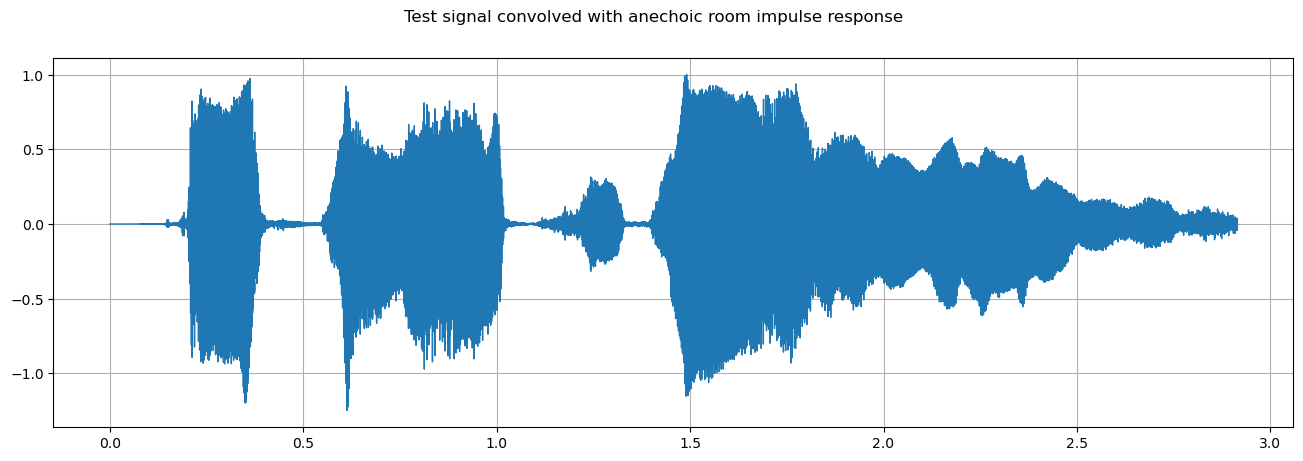

In [30]:
module_functions_conv.plot_waveform(audio_conv_anechoic, sampling_frequency, title="Test signal convolved with anechoic room impulse response")

### Señal de audio de prueba convolucionada con respuesta impulso en sala reverberante

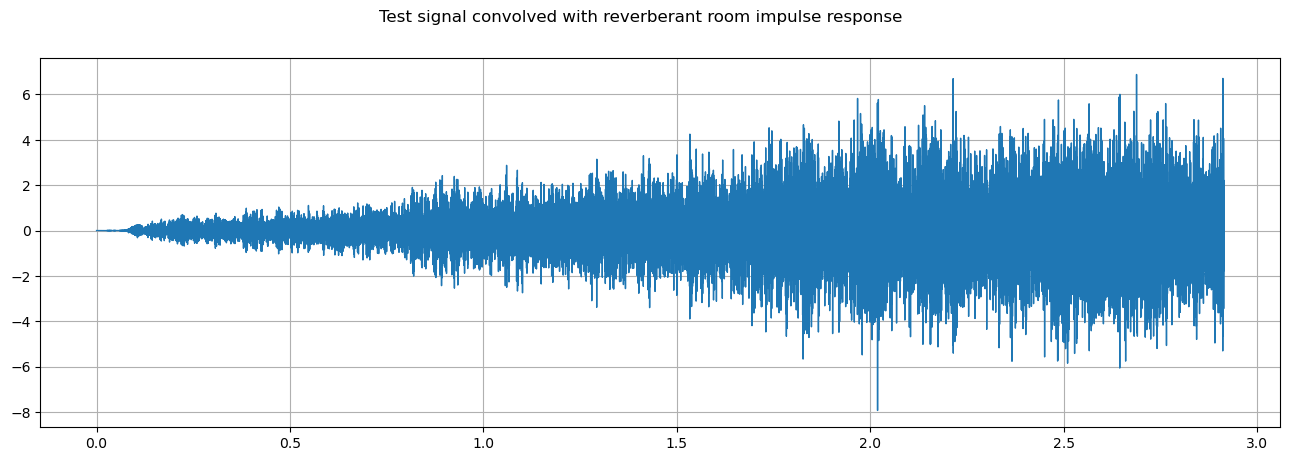

In [31]:
module_functions_conv.plot_waveform(audio_conv_rev, sampling_frequency, title="Test signal convolved with reverberant room impulse response")

## Espectrogramas de los datos de audio

> Los espectrogramas son representaciones en dos dimensiones (como si se tratara de una imagen) de la magnitud cuadrática de la transformada de Fourier en ventanas de tiempo corto (STFT)
[https://pytorch.org/audio/main/generated/torchaudio.transforms.Spectrogram.html] 

> Esta imagen describe sobre el eje horizontal el tiempo. Mientras que sobre el eje vertical se representa la frecuencia. 

> En un punto dado sobre el espectrograma, el valor del espectrograma en dicho punto se describe por la intensidad o color en la imagen.

> Mientras más intenso el color, mayor es la intensidad de los datos de audio. En términos de energía, a mayor intensidad o color, mayor es la energía en esos puntos.

> Los espectrogramas nos sirven para observar el contenido de energía de los datos de audio y cómo ésta energía va cambiando a lo largo del tiempo.

### Espectrograma de la señal impulso capturada en sala anecoica

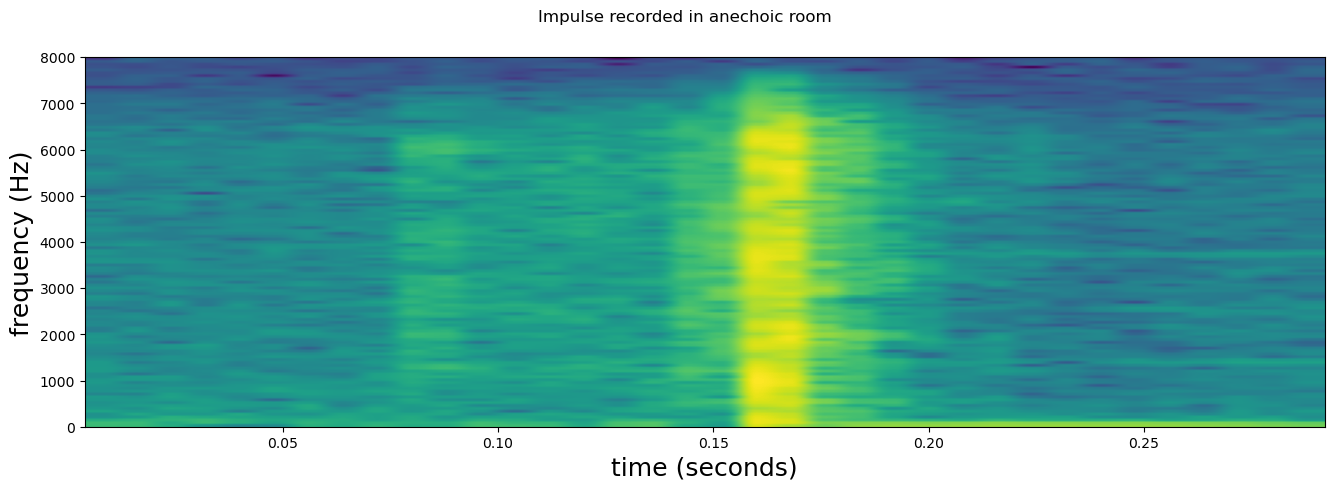

In [32]:
module_functions.plot_specgram(audio_anechoic, sampling_frequency, \
                    title=f"Impulse recorded in anechoic room")

### Espectrograma de la señal impulso capturada en sala reverberante

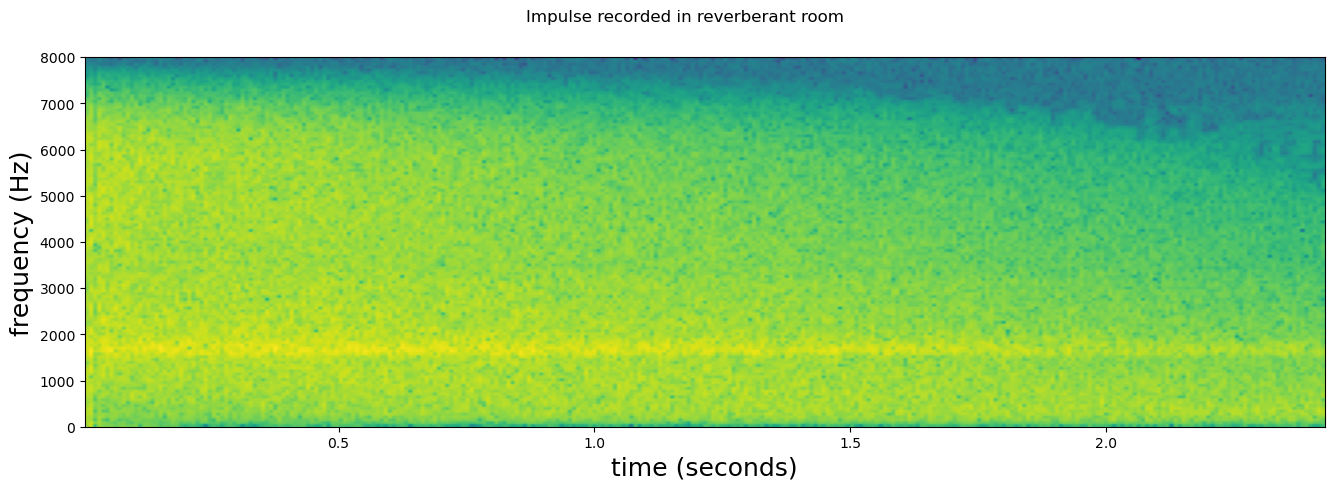

In [33]:
module_functions.plot_specgram(audio_reverberant, sampling_frequency, \
                    title=f"Impulse recorded in reverberant room")

### Espectrograma de la señal de prueba 

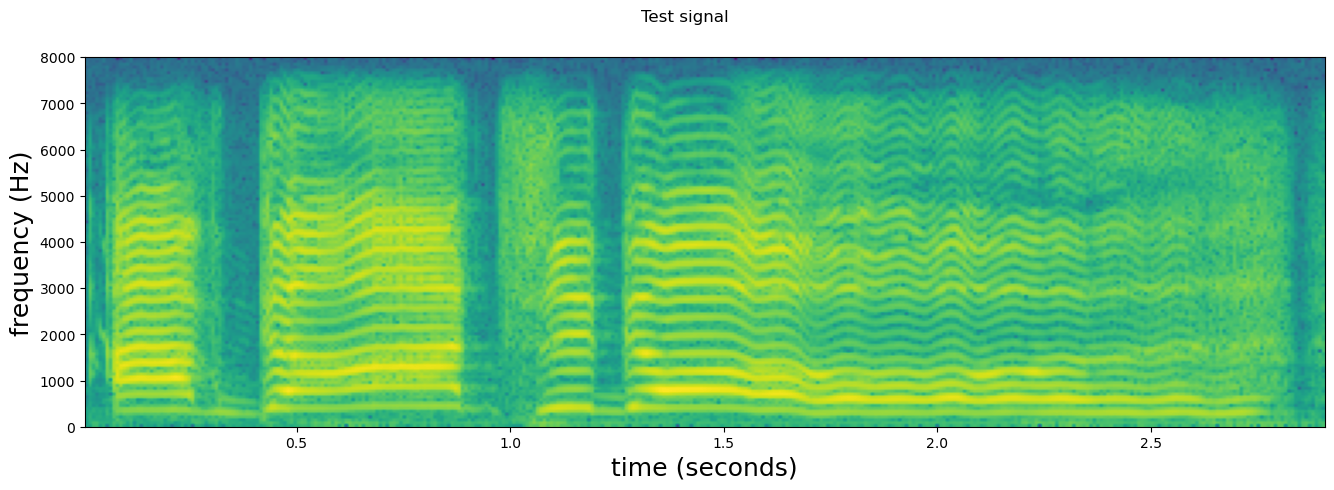

In [34]:
module_functions.plot_specgram(audio_happybirthday, sampling_frequency, \
                    title=f"Test signal")

### Espectrograma de la señal de prueba convolucionada con impulso capturado en sala anecoica

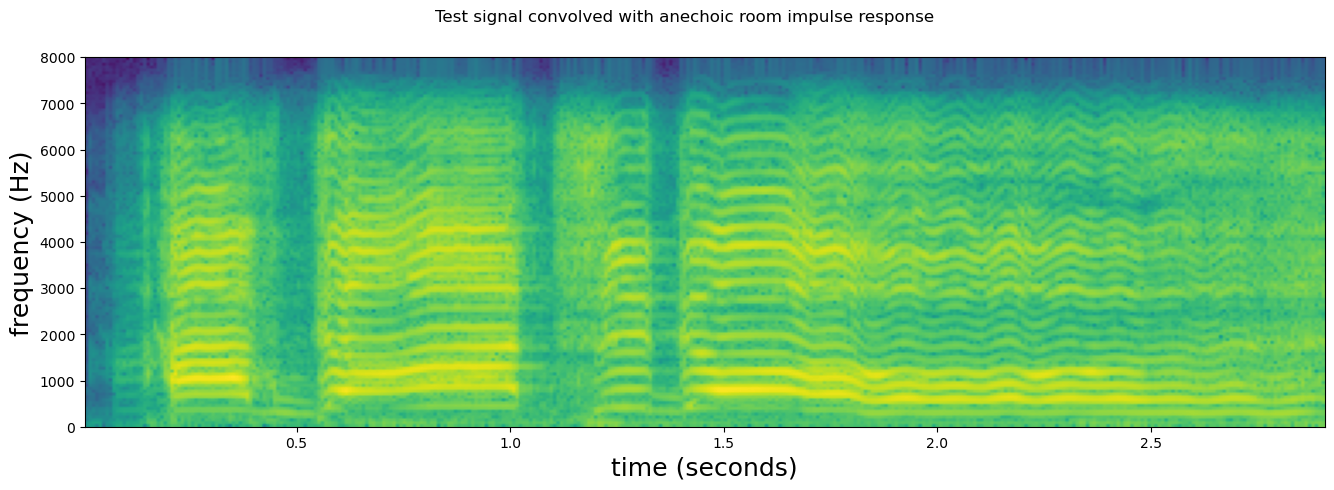

In [35]:
module_functions.plot_specgram(audio_conv_anechoic, sampling_frequency, \
                    title=f"Test signal convolved with anechoic room impulse response")

### Espectrograma de la señal de prueba convolucionada con impulso capturado en sala reverberante

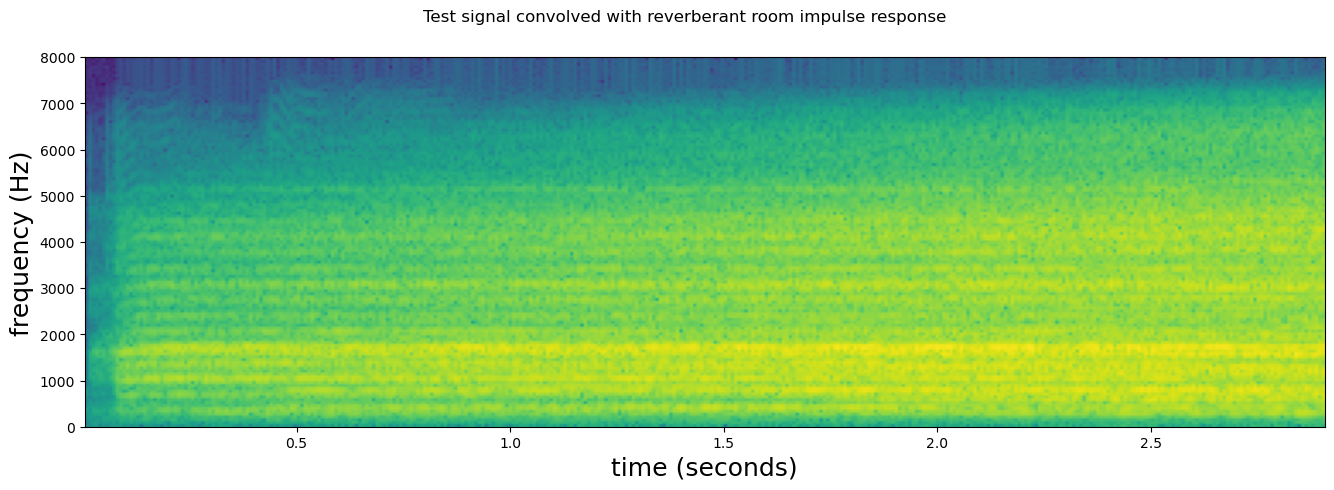

In [36]:
module_functions.plot_specgram(audio_conv_rev, sampling_frequency, \
                    title=f"Test signal convolved with reverberant room impulse response")